# PIGB

Here we start to mess around with the temporary algorithm we might wanna consider as a near-the-optimal object of the paper.

Monte Carlo runs: 100%|██████████| 100/100 [05:50<00:00,  3.50s/it]


Algorithm vs fixed-point comparison
n_mc: 100
noise_std: 5.000

Point (80.0, 0.2): mean diff = -1.0436e-01, sd diff = 4.9789e-03, rmse diff = 1.0448e-01
Point (100.0, 0.5): mean diff = -1.8116e-01, sd diff = 5.1543e-03, rmse diff = 1.8123e-01
Point (120.0, 0.8): mean diff = -4.2265e-04, sd diff = 2.6108e-03, rmse diff = 2.6319e-03


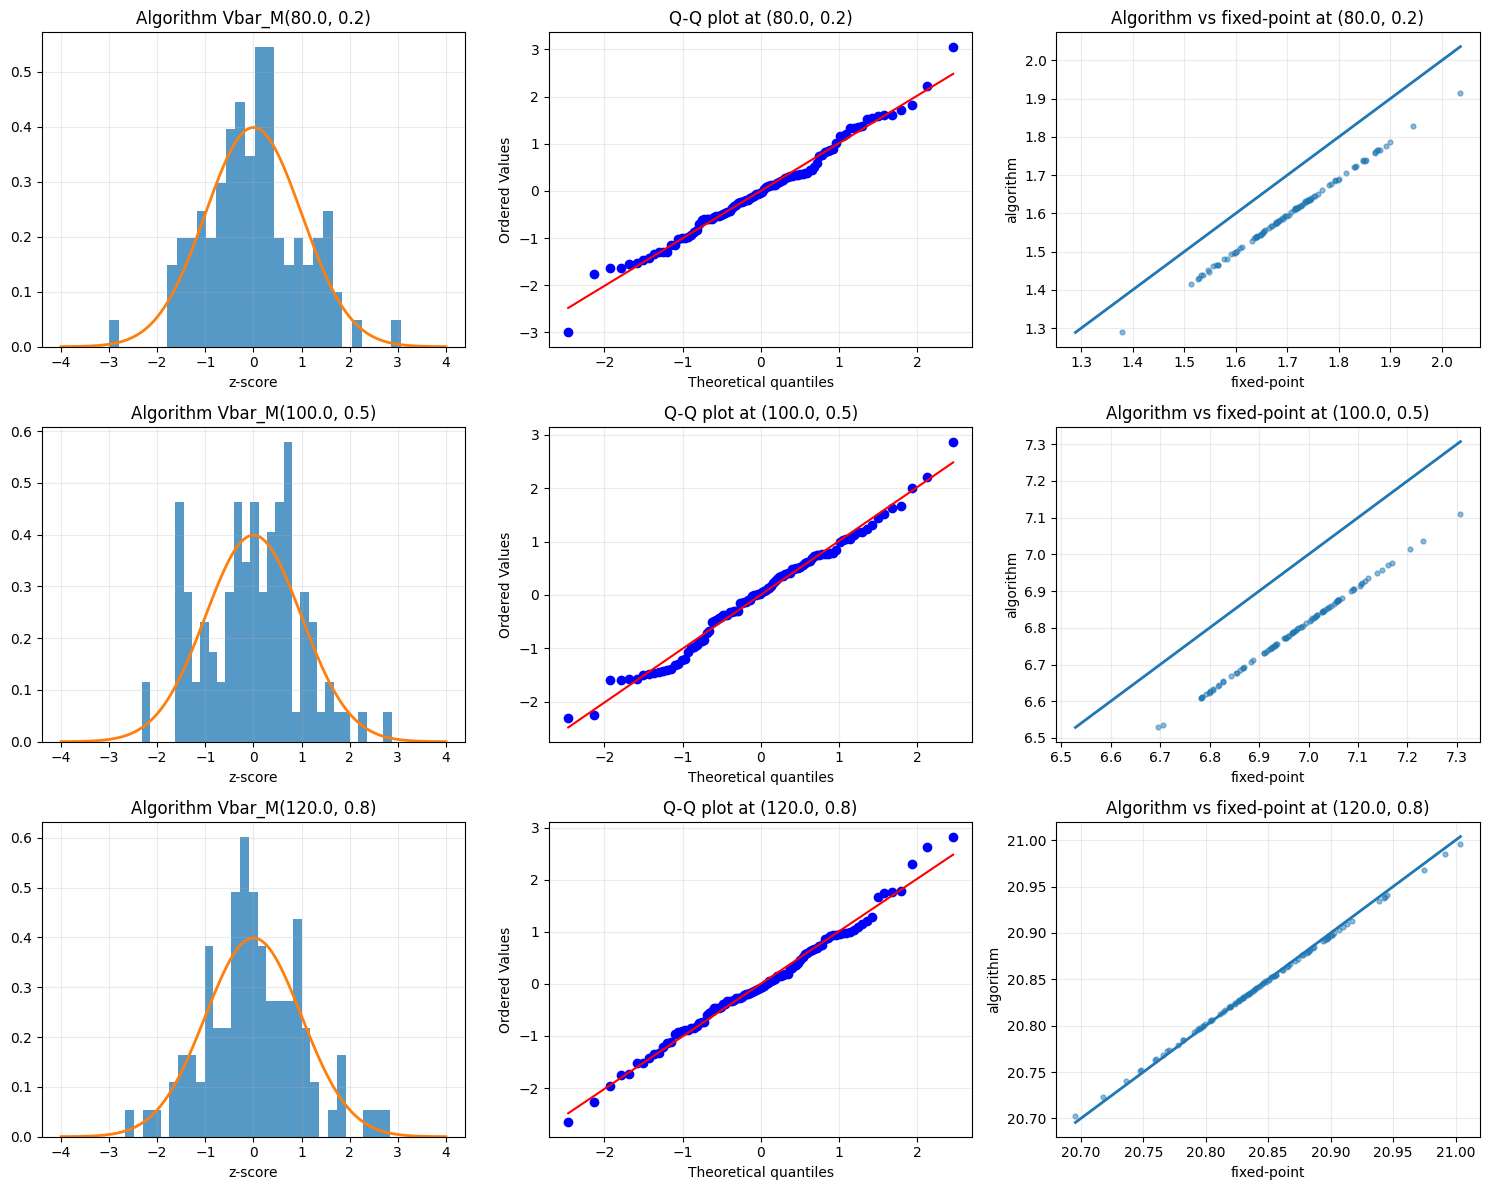

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import norm, probplot
from sklearn.linear_model import Ridge

# ============================================================
# 1. Black-Scholes setup
# ============================================================
K = 100.0
r = 0.05
sigma = 0.2
T = 1.0
S_min = 0.0
S_max = 300.0

def bs_call(Sv, tv, K, r, sigma, T):
    tau = T - tv
    Sv = np.asarray(Sv, dtype=float)
    if np.isscalar(tv):
        if tau <= 1e-12:
            return np.maximum(Sv - K, 0.0)
        s = np.maximum(Sv, 1e-300)
        st = np.sqrt(tau)
        d1 = (np.log(s / K) + (r + 0.5 * sigma**2) * tau) / (sigma * st)
        d2 = d1 - sigma * st
        return s * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)
    raise ValueError("tv should be scalar")

def bs_operator(V, V_t, V_S, V_SS, S):
    return V_t + 0.5 * sigma**2 * (S**2) * V_SS + r * S * V_S - r * V

def prior_value(S, t):
    return np.maximum(S[:, 0] - K * np.exp(-r * (T - t[:, 0])), 0.0)

# ============================================================
# 2. Fixed design / basis / collocation
# ============================================================
MASTER_SEED = 12345
rng = np.random.default_rng(MASTER_SEED)

n_obs = 2000
Nf = 2500
Ntau = 1000
Nb = 900

M_S = 18
M_t = 14
bandwidth_multiplier = 0.7

n_boost = 300
boost_lr = 0.05
ridge_alpha = 2.0

w_data = 1.0
w_phys = 1.0
w_bc = 12.0

dS_phys = 1.0
dt_phys = T / 300.0

# fixed observed-design points
S_obs = rng.uniform(max(S_min, 1e-6), S_max, size=(n_obs, 1))
t_obs = rng.uniform(0.0, T, size=(n_obs, 1))
mu_Y = np.array([bs_call(S_obs[i, 0], t_obs[i, 0], K, r, sigma, T) for i in range(n_obs)])

# fixed boundary / terminal points
S_tau = rng.uniform(max(S_min, 1e-6), S_max, size=(Ntau, 1))
t_tau = np.full((Ntau, 1), T)
y_tau = np.maximum(S_tau[:, 0] - K, 0.0)

t_b0 = rng.uniform(0.0, T, size=(Nb, 1))
S_b0 = np.full((Nb, 1), S_min)
y_b0 = np.zeros(Nb)

t_b1 = rng.uniform(0.0, T, size=(Nb, 1))
S_b1 = np.full((Nb, 1), S_max)
y_b1 = S_max - K * np.exp(-r * (T - t_b1[:, 0]))

S_bc = np.vstack([S_tau, S_b0, S_b1])
t_bc = np.vstack([t_tau, t_b0, t_b1])
y_bc = np.concatenate([y_tau, y_b0, y_b1])

# fixed interior collocation points
S_f = rng.uniform(dS_phys, S_max - dS_phys, size=(Nf, 1))
t_f = rng.uniform(dt_phys, T - dt_phys, size=(Nf, 1))

S_fp = S_f + dS_phys
S_fm = S_f - dS_phys
t_tp = t_f + dt_phys
t_tm = t_f - dt_phys

# ============================================================
# 3. RBF basis
# ============================================================
S_centers_1d = np.linspace(S_min, S_max, M_S)
t_centers_1d = np.linspace(0.0, T, M_t)
S_centers_mesh, t_centers_mesh = np.meshgrid(S_centers_1d, t_centers_1d)

centers_S = S_centers_mesh.reshape(-1, 1)
centers_t = t_centers_mesh.reshape(-1, 1)
p = centers_S.shape[0]

base_h_S = (S_max - S_min) / max(M_S - 1, 1) * 1.25
base_h_t = T / max(M_t - 1, 1) * 1.25
h_S = base_h_S * bandwidth_multiplier
h_t = base_h_t * bandwidth_multiplier

def rbf_basis(S, t):
    dS2 = (S - centers_S.T) ** 2
    dt2 = (t - centers_t.T) ** 2
    return np.exp(-0.5 * dS2 / (h_S ** 2) - 0.5 * dt2 / (h_t ** 2))

Phi_obs = rbf_basis(S_obs, t_obs)
Phi_bc = rbf_basis(S_bc, t_bc)

Phi_f  = rbf_basis(S_f,  t_f)
Phi_fp = rbf_basis(S_fp, t_f)
Phi_fm = rbf_basis(S_fm, t_f)
Phi_tp = rbf_basis(S_f,  t_tp)
Phi_tm = rbf_basis(S_f,  t_tm)

S_int = S_f[:, 0]
A_t  = (Phi_tp - Phi_tm) / (2.0 * dt_phys)
A_S  = (Phi_fp - Phi_fm) / (2.0 * dS_phys)
A_SS = (Phi_fp - 2.0 * Phi_f + Phi_fm) / (dS_phys ** 2)
A_int = (
    A_t
    + 0.5 * sigma**2 * (S_int[:, None] ** 2) * A_SS
    + r * S_int[:, None] * A_S
    - r * Phi_f
)

# lifting evaluations
phi_obs = prior_value(S_obs, t_obs)
phi_bc = prior_value(S_bc, t_bc)
phi_int = prior_value(S_f, t_f)

phi_fp = prior_value(S_fp, t_f)
phi_fm = prior_value(S_fm, t_f)
phi_tp = prior_value(S_f, t_tp)
phi_tm = prior_value(S_f, t_tm)

phi_t = (phi_tp - phi_tm) / (2.0 * dt_phys)
phi_S = (phi_fp - phi_fm) / (2.0 * dS_phys)
phi_SS = (phi_fp - 2.0 * phi_int + phi_fm) / (dS_phys ** 2)
Lphi_int = phi_t + 0.5 * sigma**2 * (S_int ** 2) * phi_SS + r * S_int * phi_S - r * phi_int

# fixed-point matrices for comparison
Q = (
    w_data * (Phi_obs.T @ Phi_obs)
    + w_phys * (A_int.T @ A_int)
    + w_bc * (Phi_bc.T @ Phi_bc)
)
Q += 1e-10 * np.eye(Q.shape[0])

b0 = (
    - w_data * (Phi_obs.T @ phi_obs)
    - w_phys * (A_int.T @ Lphi_int)
    + w_bc * (Phi_bc.T @ (y_bc - phi_bc))
)

Q_inv = np.linalg.inv(Q)
B = Q_inv @ (w_data * Phi_obs.T)
a = Q_inv @ b0

# ============================================================
# 4. Test points
# ============================================================
test_points = [
    (80.0, 0.2),
    (100.0, 0.5),
    (120.0, 0.8),
]
Phi_test = np.array([rbf_basis(np.array([[S0]]), np.array([[t0]])).reshape(-1) for S0, t0 in test_points])
prior_test = np.array([prior_value(np.array([[S0]]), np.array([[t0]]) )[0] for S0, t0 in test_points])
true_test = np.array([bs_call(S0, t0, K, r, sigma, T) for S0, t0 in test_points])

# ============================================================
# 5. Training function
# ============================================================
def train_one_run(Y):
    coef_raw = np.zeros(p)
    coef_avg = np.zeros(p)

    pred_obs_raw = phi_obs.copy()
    pred_bc_raw  = phi_bc.copy()
    pred_f_raw   = phi_int.copy()
    pred_fp_raw  = phi_fp.copy()
    pred_fm_raw  = phi_fm.copy()
    pred_tp_raw  = phi_tp.copy()
    pred_tm_raw  = phi_tm.copy()

    pred_obs_avg = phi_obs.copy()
    pred_bc_avg  = phi_bc.copy()
    pred_f_avg   = phi_int.copy()
    pred_fp_avg  = phi_fp.copy()
    pred_fm_avg  = phi_fm.copy()
    pred_tp_avg  = phi_tp.copy()
    pred_tm_avg  = phi_tm.copy()

    for ep in range(1, n_boost + 1):
        data_res = Y - pred_obs_avg

        V = pred_f_avg
        V_t = (pred_tp_avg - pred_tm_avg) / (2.0 * dt_phys)
        V_S = (pred_fp_avg - pred_fm_avg) / (2.0 * dS_phys)
        V_SS = (pred_fp_avg - 2.0 * pred_f_avg + pred_fm_avg) / (dS_phys ** 2)
        pde_res = bs_operator(V, V_t, V_S, V_SS, S_int)

        bc_res = y_bc - pred_bc_avg

        X_stage = np.vstack([Phi_obs, A_int, Phi_bc])
        y_stage = np.concatenate([data_res, -pde_res, bc_res])
        w_stage = np.concatenate([
            np.full(len(Y), w_data),
            np.full(Nf, w_phys),
            np.full(len(y_bc), w_bc),
        ])

        reg = Ridge(alpha=ridge_alpha, fit_intercept=False)
        reg.fit(X_stage, y_stage, sample_weight=w_stage)
        beta_stage = reg.coef_

        delta = boost_lr * beta_stage
        coef_raw += delta

        pred_obs_raw += Phi_obs @ delta
        pred_bc_raw  += Phi_bc @ delta
        pred_f_raw   += Phi_f @ delta
        pred_fp_raw  += Phi_fp @ delta
        pred_fm_raw  += Phi_fm @ delta
        pred_tp_raw  += Phi_tp @ delta
        pred_tm_raw  += Phi_tm @ delta

        coef_avg = ((ep - 1.0) / ep) * coef_avg + (1.0 / ep) * coef_raw

        pred_obs_avg = ((ep - 1.0) / ep) * pred_obs_avg + (1.0 / ep) * pred_obs_raw
        pred_bc_avg  = ((ep - 1.0) / ep) * pred_bc_avg  + (1.0 / ep) * pred_bc_raw
        pred_f_avg   = ((ep - 1.0) / ep) * pred_f_avg   + (1.0 / ep) * pred_f_raw
        pred_fp_avg  = ((ep - 1.0) / ep) * pred_fp_avg  + (1.0 / ep) * pred_fp_raw
        pred_fm_avg  = ((ep - 1.0) / ep) * pred_fm_avg  + (1.0 / ep) * pred_fm_raw
        pred_tp_avg  = ((ep - 1.0) / ep) * pred_tp_avg  + (1.0 / ep) * pred_tp_raw
        pred_tm_avg  = ((ep - 1.0) / ep) * pred_tm_avg  + (1.0 / ep) * pred_tm_raw

    return coef_avg

# ============================================================
# 6. Monte Carlo over full training runs
# ============================================================
n_mc = 100
noise_std = 5.0

coef_alg = np.zeros((n_mc, p))
coef_fp = np.zeros((n_mc, p))
value_alg = np.zeros((n_mc, len(test_points)))
value_fp = np.zeros((n_mc, len(test_points)))

for b in tqdm(range(n_mc), desc="Monte Carlo runs"):
    eps = rng.normal(0.0, noise_std, size=n_obs)
    Y = mu_Y + eps

    c_alg = train_one_run(Y)
    c_fp = B @ Y + a

    coef_alg[b] = c_alg
    coef_fp[b] = c_fp

    for j in range(len(test_points)):
        value_alg[b, j] = prior_test[j] + Phi_test[j] @ c_alg
        value_fp[b, j] = prior_test[j] + Phi_test[j] @ c_fp

# ============================================================
# 7. Compare algorithm vs fixed-point
# ============================================================
print("===================================================")
print("Algorithm vs fixed-point comparison")
print("===================================================")
print(f"n_mc: {n_mc}")
print(f"noise_std: {noise_std:.3f}")
print("")

for j, (S0, t0) in enumerate(test_points):
    diff = value_alg[:, j] - value_fp[:, j]
    print(
        f"Point ({S0:.1f}, {t0:.1f}): "
        f"mean diff = {diff.mean():.4e}, "
        f"sd diff = {diff.std(ddof=1):.4e}, "
        f"rmse diff = {np.sqrt(np.mean(diff**2)):.4e}"
    )

# ============================================================
# 8. Standardize algorithm outputs and plot
# ============================================================
value_alg_std = (value_alg - value_alg.mean(axis=0)) / value_alg.std(axis=0, ddof=1)

fig, ax = plt.subplots(len(test_points), 3, figsize=(15, 4 * len(test_points)))
if len(test_points) == 1:
    ax = np.array([ax])

for i, (S0, t0) in enumerate(test_points):
    z = value_alg_std[:, i]

    # histogram
    ax[i, 0].hist(z, bins=30, density=True, alpha=0.75)
    xx = np.linspace(-4, 4, 400)
    ax[i, 0].plot(xx, norm.pdf(xx), lw=2)
    ax[i, 0].set_title(f"Algorithm Vbar_M({S0:.1f}, {t0:.1f})")
    ax[i, 0].set_xlabel("z-score")
    ax[i, 0].grid(alpha=0.25)

    # QQ
    probplot(z, dist="norm", plot=ax[i, 1])
    ax[i, 1].set_title(f"Q-Q plot at ({S0:.1f}, {t0:.1f})")
    ax[i, 1].grid(alpha=0.25)

    # algorithm vs fixed point scatter
    ax[i, 2].scatter(value_fp[:, i], value_alg[:, i], s=12, alpha=0.5)
    lo = min(value_fp[:, i].min(), value_alg[:, i].min())
    hi = max(value_fp[:, i].max(), value_alg[:, i].max())
    ax[i, 2].plot([lo, hi], [lo, hi], lw=2)
    ax[i, 2].set_title(f"Algorithm vs fixed-point at ({S0:.1f}, {t0:.1f})")
    ax[i, 2].set_xlabel("fixed-point")
    ax[i, 2].set_ylabel("algorithm")
    ax[i, 2].grid(alpha=0.25)

plt.tight_layout()
plt.show()